# 04 — Monthly metric series audit

**Propósito.** Auditar, una por una, las series mensuales disponibles de métricas contables para detectar anomalías, saltos, huecos, cambios de signo, valores extremos y problemas de cobertura.

Esta notebook no reemplaza a `02_operating_result_report.ipynb`. Al contrario: delega en esa notebook la historia temporal principal y usa sus salidas como una de las fuentes mensuales. Acá el foco es más de QA/diagnóstico:

> mirar cada métrica en el tiempo, con guía, sin convertirlo en una tarea tediosa.

## Pregunta humana

¿Qué métricas muestran patrones raros, rupturas de régimen, huecos o saltos que conviene revisar antes de usar los números en reportes profesionales?

## Usuario

- Matías, para auditar antes de circular reportes;
- agentes/Codex, para detectar posibles problemas de pipeline;
- eventualmente soporte técnico para explicar por qué una afirmación debe quedar como caveat.

## No hace

- No redefine contabilidad.
- No decide saldo jurídico final.
- No produce meeting packs.
- No fuerza que todas las métricas sean mensuales si la fuente no existe.
- No mezcla más de 2–3 métricas por gráfico grupal.

## Outputs

`out/professional_pack/latest/monthly_series_audit/`

- `monthly_series_selected.csv`
- `metric_series_catalog.csv`
- `metric_anomaly_summary.csv`
- `metric_anomaly_events.csv`
- `plot_plan.csv`
- `monthly_series_audit_report.md`
- `monthly_series_audit_report.html`
- `figures/individual/*.png`
- `figures/groups/*.png`

## 0. Parámetros de revisión

Esta notebook está pensada para correr completa, pero la lectura humana se organiza con una cola de revisión.

- Primero miramos cobertura y catálogo.
- Después priorizamos métricas con anomalías.
- Luego generamos plots individuales para todas las métricas disponibles.
- Finalmente generamos plots grupales con máximo 2–3 series.

In [1]:
from pathlib import Path
import re
import json
import math
import html
import textwrap
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------- User parameters ----------
REPORTING_START = "2022-01-01"
REPORTING_END = "2026-06-30"   # cierre semestral 2026
INLINE_REVIEW_LIMIT = 12       # how many metric cards/plots to display inline
GENERATE_ALL_INDIVIDUAL_PLOTS = True
MAX_GROUP_SERIES = 3
OUTPUT_PERIOD = "latest"

# ---------- Resolve repo root ----------
cwd = Path.cwd().resolve()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "accounting").exists() and (p / "out").exists():
            return p
    # fallback: if running from notebooks/accounting
    if start.name == "accounting" and start.parent.name == "notebooks":
        return start.parents[1]
    return start

REPO = find_repo_root(cwd)
OUT = REPO / "out"
METRICS = OUT / "metrics" / "latest"
DEBT = OUT / "debt_resolution" / "latest"
RUN = OUT / "run" / "accounting" / "latest"
PROF = OUT / "professional_pack" / OUTPUT_PERIOD
OPERATING = PROF / "operating_result"
AUDIT = PROF / "monthly_series_audit"
FIG_INDIV = AUDIT / "figures" / "individual"
FIG_GROUPS = AUDIT / "figures" / "groups"

for p in [AUDIT, FIG_INDIV, FIG_GROUPS]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Repo: {REPO}")
print(f"Metrics: {METRICS}")
print(f"Operating result outputs: {OPERATING}")
print(f"Audit output: {AUDIT}")

Repo: /home/matias/repos/accounting-backend
Metrics: /home/matias/repos/accounting-backend/out/metrics/latest
Operating result outputs: /home/matias/repos/accounting-backend/out/professional_pack/latest/operating_result
Audit output: /home/matias/repos/accounting-backend/out/professional_pack/latest/monthly_series_audit


## 1. Helpers de carga y normalización

La primera tarea es descubrir fuentes mensuales sin asumir demasiado sobre el estado del pipeline. La notebook busca:

1. `out/professional_pack/latest/operating_result/operating_result_monthly.csv`
2. `out/metrics/latest/metric_values.csv`
3. `out/metrics/latest/metric_registry.csv`
4. `out/metrics/latest/metric_views/*.csv`

La regla de seguridad es simple: si una fuente no existe, se registra como faltante; no se inventan datos.

In [2]:
def read_csv(path, **kwargs):
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(path, **kwargs)
    except Exception as e:
        print(f"Could not read {path}: {e}")
        return pd.DataFrame()

def norm_col(c):
    return re.sub(r"[^a-z0-9]+", "_", str(c).strip().lower()).strip("_")

def find_col(df, candidates):
    if df is None or df.empty:
        return None
    cols = list(df.columns)
    norm_map = {norm_col(c): c for c in cols}
    for cand in candidates:
        if cand in cols:
            return cand
        nc = norm_col(cand)
        if nc in norm_map:
            return norm_map[nc]
    return None

def parse_month_value(x):
    if pd.isna(x):
        return pd.NaT
    s = str(x).strip()
    # YYYY-MM
    m = re.match(r"^(\d{4})-(\d{1,2})$", s)
    if m:
        return pd.Timestamp(int(m.group(1)), int(m.group(2)), 1)
    # YYYY-MM-DD
    try:
        dt = pd.to_datetime(s, errors="coerce")
        if pd.notna(dt):
            return pd.Timestamp(dt.year, dt.month, 1)
    except Exception:
        pass
    # YYYYQn -> quarter start month
    m = re.match(r"^(\d{4})Q([1-4])$", s, flags=re.I)
    if m:
        q = int(m.group(2))
        return pd.Timestamp(int(m.group(1)), 3*(q-1)+1, 1)
    # YYYYHn -> semester start month
    m = re.match(r"^(\d{4})H([12])$", s, flags=re.I)
    if m:
        h = int(m.group(2))
        return pd.Timestamp(int(m.group(1)), 1 if h == 1 else 7, 1)
    # YYYY -> year start
    m = re.match(r"^(\d{4})$", s)
    if m:
        return pd.Timestamp(int(m.group(1)), 1, 1)
    return pd.NaT

def month_str(ts):
    if pd.isna(ts):
        return None
    return pd.Timestamp(ts).strftime("%Y-%m")

def money(x):
    if pd.isna(x):
        return "s/d"
    try:
        return "$ " + f"{float(x):,.0f}".replace(",", ".")
    except Exception:
        return str(x)

def safe_metric_filename(metric_id):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(metric_id)).strip("_")[:180]

def classify_namespace(metric_id):
    s = str(metric_id)
    return s.split(".", 1)[0] if "." in s else "VIEW"

def metric_question(metric_id):
    ns = classify_namespace(metric_id)
    mid = str(metric_id)
    if ns == "IS":
        if "RENT" in mid or "REVENUE" in mid:
            return "¿Cómo evoluciona la generación operativa de ingresos?"
        if "OPEX" in mid:
            return "¿Cómo evolucionan los costos de sostener la operación?"
        if "NET" in mid:
            return "¿Qué muestra el margen después de costos, sin mezclarlo con caja o deuda?"
        return "¿Qué patrón operativo muestra esta métrica?"
    if ns == "FUND":
        return "¿Cuándo y cuánto funding familiar hizo falta para sostener la caja?"
    if ns == "DIST":
        return "¿Cuándo aparecen retiros o salidas distributivas relevantes?"
    if ns == "CF":
        return "¿Qué movimiento de caja muestra esta serie?"
    if ns == "BS":
        return "¿Cómo evoluciona este stock de cierre?"
    if ns == "ID":
        return "¿Cómo evoluciona la deuda interna o exposición entre actores?"
    if ns == "COV":
        return "¿Qué lectura de cobertura humana intenta resumir esta serie?"
    return "¿Qué patrón mensual muestra esta fuente auxiliar?"

def review_hint(metric_id):
    ns = classify_namespace(metric_id)
    mid = str(metric_id)
    hints = []
    if ns in {"IS", "FUND", "DIST", "CF"}:
        hints.append("Mirar picos, meses faltantes y cambios de signo.")
        hints.append("Para flows, un mes aislado enorme puede ser evento real o clasificación errónea.")
    if ns == "BS" or "CLOSING" in mid or "OPEN" in mid:
        hints.append("Para stocks, mirar saltos de nivel y meses donde el saldo cae a cero inesperadamente.")
    if "LEGACY" in mid or mid.startswith("IS.NET.AFTER_COSTS") or mid.startswith("IS.INCOME.TOTAL"):
        hints.append("Cuidado: puede ser métrica legacy o semanticamente mezclada.")
    if "DEBT" in mid or ns == "ID":
        hints.append("Cruzar contra debt_open_items y repayment_events antes de afirmar saldo final.")
    return " ".join(hints) if hints else "Mirar continuidad, magnitud y coherencia contra métricas relacionadas."

## 2. Cargar registro, valores y salidas del reporte temporal

Esta sección no muestra todavía conclusiones. Solo arma el inventario de fuentes disponibles.

In [3]:
metric_registry = read_csv(METRICS / "metric_registry.csv")
metric_values = read_csv(METRICS / "metric_values.csv")
validation_report = read_csv(METRICS / "validation_report.csv")
operating_monthly = read_csv(OPERATING / "operating_result_monthly.csv")

RUN_VIEWS = RUN / "views"
STAGE_D = {
    "per_flow_time_long": RUN / "per_flow_time_long.freq=M.csv",
    "box_balance_time_long": RUN / "box_balance_time_long.freq=M.csv",
    "box_flow_balance_time_long": RUN / "box_flow_balance_time_long.freq=M.csv",
    "ledger_canonical": RUN / "ledger_canonical.csv",
    "daily_cash_position": RUN / "daily_cash_position.csv",
    "debt_balance_monthly": DEBT / "debt_balance_monthly.csv",
    "v_contributions_monthly": RUN_VIEWS / "v_contributions_monthly.csv",
    "v_opex_category_monthly": RUN_VIEWS / "v_opex_category_monthly.csv",
    "income_statement_monthly_last6": RUN_VIEWS / "income_statement_monthly_last6.csv",
}
stage_d_frames = {name: read_csv(path) for name, path in STAGE_D.items()}

metric_view_files = sorted((METRICS / "metric_views").glob("*.csv")) if (METRICS / "metric_views").exists() else []
run_view_files = sorted(RUN_VIEWS.glob("*.csv")) if RUN_VIEWS.exists() else []

source_status = pd.DataFrame([
    {"source": "metric_registry", "path": str(METRICS / "metric_registry.csv"), "exists": not metric_registry.empty, "rows": len(metric_registry), "cols": len(metric_registry.columns) if not metric_registry.empty else 0},
    {"source": "metric_values", "path": str(METRICS / "metric_values.csv"), "exists": not metric_values.empty, "rows": len(metric_values), "cols": len(metric_values.columns) if not metric_values.empty else 0},
    {"source": "validation_report", "path": str(METRICS / "validation_report.csv"), "exists": not validation_report.empty, "rows": len(validation_report), "cols": len(validation_report.columns) if not validation_report.empty else 0},
    {"source": "operating_result_monthly", "path": str(OPERATING / "operating_result_monthly.csv"), "exists": not operating_monthly.empty, "rows": len(operating_monthly), "cols": len(operating_monthly.columns) if not operating_monthly.empty else 0},
    *[{"source": name, "path": str(path), "exists": not stage_d_frames[name].empty, "rows": len(stage_d_frames[name]), "cols": len(stage_d_frames[name].columns) if not stage_d_frames[name].empty else 0} for name, path in STAGE_D.items()],
    {"source": "metric_views_csv", "path": str(METRICS / "metric_views"), "exists": len(metric_view_files) > 0, "rows": len(metric_view_files), "cols": 0},
    {"source": "run_views_csv", "path": str(RUN_VIEWS), "exists": len(run_view_files) > 0, "rows": len(run_view_files), "cols": 0},
])

source_status.to_csv(AUDIT / "source_status.csv", index=False)
source_status


,source,path,exists,rows,cols
0,metric_registry,/home/matias/repos/accounting-backend/out/metr...,True,17,14
1,metric_values,/home/matias/repos/accounting-backend/out/metr...,True,287,10
2,validation_report,/home/matias/repos/accounting-backend/out/metr...,True,1,4
3,operating_result_monthly,/home/matias/repos/accounting-backend/out/prof...,True,54,20


## 3. Construir una tabla larga mensual de series

Acá convertimos varias fuentes a una forma común:

```text
metric_id | month | value | source | source_file | source_column
```

La fuente preferida es `operating_result_monthly.csv`, porque ya fue diseñada como spine temporal. Después se agregan métricas mensuales de `metric_values.csv` si existen y rollups de `metric_views/` como soporte auxiliar.

In [4]:
BASE_COLS = ["metric_id", "month", "value", "source", "source_file", "source_column"]

def empty_long():
    return pd.DataFrame(columns=BASE_COLS)

def add_records_from_wide(df, path, source, mapping, month_candidates=("period_month", "month", "period", "date", "fecha", "period_start")):
    if df.empty:
        return empty_long()
    month_col = find_col(df, list(month_candidates))
    if not month_col:
        return empty_long()
    temp = df.copy()
    temp["_month"] = temp[month_col].map(parse_month_value)
    rows = []
    for col, metric_id in mapping.items():
        actual_col = find_col(temp, [col])
        if not actual_col:
            continue
        vals = pd.to_numeric(temp[actual_col], errors="coerce")
        for m, v in zip(temp["_month"], vals):
            if pd.notna(m) and pd.notna(v):
                rows.append({"metric_id": metric_id, "month": month_str(m), "value": float(v), "source": source, "source_file": str(path), "source_column": actual_col})
    return pd.DataFrame(rows, columns=BASE_COLS)

def long_from_operating_monthly(df):
    return add_records_from_wide(df, OPERATING / "operating_result_monthly.csv", "operating_result_monthly", {
        "rent_total": "IS.RENT.TOTAL", "revenue_total": "IS.REVENUE.TOTAL", "opex_total": "IS.OPEX.TOTAL",
        "net_operating": "IS.NET.OPERATING", "funding_total": "FUND.CONTRIB.TOTAL", "draws_total": "DIST.DRAWS.PERSONAL",
        "cash_closing": "BS.CASH.TOTAL", "debt_closing": "BS.DEBT.TOTAL.OPEN",
        "legacy_income_total": "IS.INCOME.TOTAL", "legacy_net_after_costs": "IS.NET.AFTER_COSTS",
    })

def long_from_metric_values(df):
    if df.empty:
        return empty_long()
    metric_col = find_col(df, ["metric_id", "metric"])
    value_col = find_col(df, ["value", "metric_value", "amount", "current_value", "value_ars", "value_usd"])
    period_col = find_col(df, ["period", "period_id", "period_label", "month", "date", "period_start"])
    grain_col = find_col(df, ["period_grain", "grain", "freq", "frequency", "period_type", "period_freq"])
    if not metric_col or not value_col or not period_col:
        return empty_long()
    temp = df.copy()
    if grain_col:
        temp = temp[temp[grain_col].astype(str).str.upper().eq("M")].copy()
    temp["_month"] = temp[period_col].map(parse_month_value)
    temp["_value"] = pd.to_numeric(temp[value_col], errors="coerce")
    temp = temp[pd.notna(temp["_month"]) & pd.notna(temp["_value"])].copy()
    return pd.DataFrame({"metric_id": temp[metric_col].astype(str), "month": temp["_month"].map(month_str), "value": temp["_value"].astype(float), "source": "metric_values_monthly", "source_file": str(METRICS / "metric_values.csv"), "source_column": value_col})

def long_from_per_flow(df):
    if df.empty: return empty_long()
    month_col = find_col(df, ["period_month", "month", "period", "date"])
    value_col = find_col(df, ["amount", "value", "total", "value_ars", "signed_amount"])
    flow_col = find_col(df, ["flow", "flow_name", "flujo", "flujo_tipo", "category", "bucket", "line_item"])
    if not month_col or not value_col: return empty_long()
    t=df.copy(); t["_month"]=t[month_col].map(parse_month_value); t["_value"]=pd.to_numeric(t[value_col], errors="coerce")
    def mask(words):
        if not flow_col: return pd.Series(False, index=t.index)
        s=t[flow_col].astype(str).str.lower(); return pd.concat([s.str.contains(w, na=False) for w in words], axis=1).any(axis=1)
    specs={"IS.RENT.TOTAL":mask(["rent","renta","alquiler","revenue","ingreso"]),"IS.OPEX.TOTAL":mask(["opex","expense","gasto","costo"]),"FUND.CONTRIB.TOTAL":mask(["contrib","fund","aporte"]),"DIST.DRAWS.PERSONAL":mask(["draw","retiro","distribution","personal"])}
    rows=[]
    for mid,m in specs.items():
        g=t[m & pd.notna(t["_month"]) & pd.notna(t["_value"])].groupby("_month")["_value"].sum()
        for mo,v in g.items(): rows.append({"metric_id":mid,"month":month_str(mo),"value":float(v),"source":"per_flow_time_long","source_file":str(STAGE_D["per_flow_time_long"]),"source_column":value_col})
    return pd.DataFrame(rows, columns=BASE_COLS)

def long_from_daily_cash(df):
    if df.empty: return empty_long()
    date_col=find_col(df,["date","day","fecha","period_date"]); value_col=find_col(df,["cash_total","cash_closing","closing_balance","balance","value","amount"]); box_col=find_col(df,["box","cash_box","account","cuenta"])
    if not date_col or not value_col: return empty_long()
    t=df.copy(); t["_dt"]=pd.to_datetime(t[date_col], errors="coerce"); t["_month"]=t["_dt"].dt.to_period("M").dt.to_timestamp(); t["_value"]=pd.to_numeric(t[value_col], errors="coerce")
    rows=[]
    if box_col:
        for key,mid in {"fb":"BS.CASH.FB","pm":"BS.CASH.PM"}.items():
            g=t[t[box_col].astype(str).str.lower().str.contains(key, na=False)].dropna(subset=["_dt","_value"]).sort_values("_dt").groupby("_month").tail(1)
            for _,r in g.iterrows(): rows.append({"metric_id":mid,"month":month_str(r["_month"]),"value":float(r["_value"]),"source":"daily_cash_position","source_file":str(STAGE_D["daily_cash_position"]),"source_column":value_col})
    g=t.dropna(subset=["_dt","_value"]).sort_values("_dt").groupby("_month").tail(1)
    for _,r in g.iterrows(): rows.append({"metric_id":"BS.CASH.TOTAL","month":month_str(r["_month"]),"value":float(r["_value"]),"source":"daily_cash_position","source_file":str(STAGE_D["daily_cash_position"]),"source_column":value_col})
    return pd.DataFrame(rows, columns=BASE_COLS)

def long_from_debt(df):
    if df.empty: return empty_long()
    return add_records_from_wide(df, STAGE_D["debt_balance_monthly"], "debt_balance_monthly", {"debt_total":"BS.DEBT.TOTAL.OPEN","total_debt":"BS.DEBT.TOTAL.OPEN","debt_closing":"BS.DEBT.TOTAL.OPEN","principal":"BS.DEBT.PRINCIPAL","interest":"BS.DEBT.INTEREST","interest_accrued":"BS.DEBT.INTEREST"})

def long_from_support_monthly(df, path, source, default_metric):
    if df.empty: return empty_long()
    month_col=find_col(df,["period_month","month","period","date"]); value_col=find_col(df,["amount","value","total","value_ars"]); metric_col=find_col(df,["metric_id","metric"])
    if not month_col or not value_col: return empty_long()
    t=df.copy(); t["_month"]=t[month_col].map(parse_month_value); t["_value"]=pd.to_numeric(t[value_col], errors="coerce")
    rows=[]
    for _,r in t[pd.notna(t["_month"]) & pd.notna(t["_value"])].iterrows():
        rows.append({"metric_id": str(r[metric_col]) if metric_col else default_metric, "month": month_str(r["_month"]), "value": float(r["_value"]), "source": source, "source_file": str(path), "source_column": value_col})
    return pd.DataFrame(rows, columns=BASE_COLS)

def long_from_metric_view_file(path):
    # last12 metric views are support only; grain audit prevents quarterly values from being treated as monthly.
    return long_from_support_monthly(read_csv(path), path, "metric_view_last12", f"VIEW.{Path(path).stem}")

parts = [long_from_operating_monthly(operating_monthly), long_from_per_flow(stage_d_frames["per_flow_time_long"]), long_from_daily_cash(stage_d_frames["daily_cash_position"]), long_from_debt(stage_d_frames["debt_balance_monthly"]), long_from_support_monthly(stage_d_frames["v_contributions_monthly"], STAGE_D["v_contributions_monthly"], "v_contributions_monthly", "FUND.CONTRIB.TOTAL"), long_from_support_monthly(stage_d_frames["v_opex_category_monthly"], STAGE_D["v_opex_category_monthly"], "v_opex_category_monthly", "IS.OPEX.TOTAL"), add_records_from_wide(stage_d_frames["income_statement_monthly_last6"], STAGE_D["income_statement_monthly_last6"], "income_statement_monthly_last6_fallback", {"rent_total":"IS.RENT.TOTAL","opex_total":"IS.OPEX.TOTAL","net_operating":"IS.NET.OPERATING"}), long_from_metric_values(metric_values)]
for path in metric_view_files: parts.append(long_from_metric_view_file(path))
monthly_long_raw = pd.concat([p for p in parts if not p.empty], ignore_index=True) if any(not p.empty for p in parts) else empty_long()
if not monthly_long_raw.empty:
    monthly_long_raw["_month_dt"] = monthly_long_raw["month"].map(parse_month_value)
    monthly_long_raw = monthly_long_raw[(monthly_long_raw["_month_dt"] >= pd.Timestamp(REPORTING_START)) & (monthly_long_raw["_month_dt"] <= pd.Timestamp(REPORTING_END))].drop(columns="_month_dt").copy()
monthly_long_raw.to_csv(AUDIT / "monthly_series_raw_sources.csv", index=False)
print(f"Raw monthly rows: {len(monthly_long_raw):,}")
print(f"Metrics discovered: {monthly_long_raw['metric_id'].nunique() if not monthly_long_raw.empty else 0}")
monthly_long_raw.head(10)


Raw monthly rows: 919
Metrics discovered: 25


,metric_id,month,value,source,source_file,source_column
0,IS.RENT.TOTAL,2022-01,0.0,operating_result_monthly,/home/matias/repos/accounting-backend/out/prof...,rent_total
1,IS.RENT.TOTAL,2022-02,0.0,operating_result_monthly,/home/matias/repos/accounting-backend/out/prof...,rent_total
2,IS.RENT.TOTAL,2022-03,0.0,operating_result_monthly,/home/matias/repos/accounting-backend/out/prof...,rent_total
3,IS.RENT.TOTAL,2022-04,0.0,operating_result_monthly,/home/matias/repos/accounting-backend/out/prof...,rent_total
4,IS.RENT.TOTAL,2022-05,0.0,operating_result_monthly,/home/matias/repos/accounting-backend/out/prof...,rent_total
5,IS.RENT.TOTAL,2022-06,0.0,operating_result_monthly,/home/matias/repos/accounting-backend/out/prof...,rent_total
6,IS.RENT.TOTAL,2022-07,0.0,operating_result_monthly,/home/matias/repos/accounting-backend/out/prof...,rent_total
7,IS.RENT.TOTAL,2022-08,0.0,operating_result_monthly,/home/matias/repos/accounting-backend/out/prof...,rent_total
8,IS.RENT.TOTAL,2022-09,0.0,operating_result_monthly,/home/matias/repos/accounting-backend/out/prof...,rent_total
9,IS.RENT.TOTAL,2022-10,0.0,operating_result_monthly,/home/matias/repos/accounting-backend/out/prof...,rent_total


## 4. Seleccionar una fuente por métrica

Una misma métrica puede aparecer en más de una fuente. Para evitar duplicaciones, se elige una fuente por métrica según:

1. prioridad de fuente;
2. cantidad de meses observados;
3. menor cantidad de duplicados.

Esto no borra la fuente original: queda en `monthly_series_raw_sources.csv`.

In [5]:
def expected_month_count(months):
    vals = sorted(pd.to_datetime(pd.Series(list(months)).map(parse_month_value).dropna().unique()))
    if not vals: return 0
    return len(pd.date_range(vals[0], vals[-1], freq="MS"))

def detect_granularity(months):
    vals = sorted(pd.to_datetime(pd.Series(list(months)).map(parse_month_value).dropna().unique()))
    observed = len(vals)
    expected = len(pd.date_range(vals[0], vals[-1], freq="MS")) if vals else 0
    coverage = observed / expected if expected else 0
    if observed == 0: return "unknown", observed, expected, coverage, "No parseable periods."
    by_year = pd.Series(vals).dt.year.value_counts()
    if observed <= max(2, len(by_year) + 1) and by_year.max() <= 1: return "yearly", observed, expected, coverage, "Only one observed period in most years."
    q_months = {1,4,7,10}
    q_share = sum(v.month in q_months for v in vals) / observed
    if observed >= 3 and q_share >= 0.8 and coverage < 0.6: return "quarterly_or_periodic", observed, expected, coverage, "Observed months are concentrated on Jan/Apr/Jul/Oct."
    if coverage >= 0.85: return "monthly_actual", observed, expected, coverage, "Observed months are mostly consecutive."
    if coverage >= 0.50: return "monthly_partial", observed, expected, coverage, "Monthly-looking source with partial coverage."
    return "unknown", observed, expected, coverage, "Sparse source that is not clearly quarterly or yearly."

def preferred_source_label(source):
    return {
        "operating_result_monthly": "1 operating_result_monthly/run view",
        "per_flow_time_long": "2 Stage D monthly materialized artifact",
        "daily_cash_position": "2 daily artifact monthly close",
        "debt_balance_monthly": "2 debt monthly close",
        "v_contributions_monthly": "1 run view monthly support",
        "v_opex_category_monthly": "1 run view monthly support",
        "ledger_monthly_derived": "3 ledger_canonical monthly derivation",
        "metric_view_last12": "4 monthly metric view last12",
        "metric_values_monthly": "5 metric_values period_grain=M",
        "metric_values_non_monthly": "6 metric_values non-monthly fallback",
    }.get(source, source)

SOURCE_PRIORITY = {"operating_result_monthly":1,"v_contributions_monthly":2,"v_opex_category_monthly":2,"per_flow_time_long":3,"daily_cash_position":3,"debt_balance_monthly":3,"ledger_monthly_derived":4,"metric_view_last12":5,"income_statement_monthly_last6_fallback":6,"metric_values_monthly":7,"metric_values_non_monthly":99,"metric_view_wide":99}

if monthly_long_raw.empty:
    monthly_source_candidates = pd.DataFrame(columns=["metric_id","source","source_file","source_column","observed_months","expected_months","coverage_ratio","detected_granularity","is_monthly_usable","reason"])
    monthly_selected = empty_long()
    source_choice = pd.DataFrame()
else:
    rows=[]
    for keys,g in monthly_long_raw.groupby(["metric_id","source","source_file","source_column"], dropna=False):
        gran, obs, exp, cov, reason = detect_granularity(g["month"])
        rows.append(dict(zip(["metric_id","source","source_file","source_column"], keys), observed_months=obs, expected_months=exp, coverage_ratio=cov, detected_granularity=gran, is_monthly_usable=gran in {"monthly_actual","monthly_partial"}, reason=reason))
    monthly_source_candidates = pd.DataFrame(rows)
    monthly_source_candidates["source_priority"] = monthly_source_candidates["source"].map(SOURCE_PRIORITY).fillna(50)
    usable = monthly_source_candidates[monthly_source_candidates["is_monthly_usable"]].copy()
    source_choice = usable.sort_values(["metric_id","source_priority","observed_months","coverage_ratio"], ascending=[True,True,False,False]).groupby("metric_id", as_index=False).head(1)
    monthly_selected = monthly_long_raw.merge(source_choice[["metric_id","source","source_file","source_column"]], on=["metric_id","source","source_file","source_column"], how="inner")
    monthly_selected = monthly_selected.groupby(["metric_id","month","source","source_file","source_column"], dropna=False)["value"].sum().reset_index()

# Audit metric_values even when not selected, so quarterly/yearly sources are visible and not mislabeled.
mv_non_monthly = []
if not metric_values.empty:
    metric_col=find_col(metric_values,["metric_id","metric"]); value_col=find_col(metric_values,["value","metric_value","amount","current_value","value_ars","value_usd"]); period_col=find_col(metric_values,["period","period_id","period_label","month","date","period_start"]); grain_col=find_col(metric_values,["period_grain","grain","freq","frequency","period_type","period_freq"])
    if metric_col and period_col:
        for mid,g in metric_values.groupby(metric_col):
            months=g[period_col].map(parse_month_value).dropna().map(month_str)
            gran, obs, exp, cov, reason=detect_granularity(months)
            if grain_col and not g[grain_col].astype(str).str.upper().eq("M").all(): reason = "metric_values period_grain is not M; " + reason
            if gran not in {"monthly_actual","monthly_partial"} or (grain_col and not g[grain_col].astype(str).str.upper().eq("M").all()):
                mv_non_monthly.append({"metric_id":str(mid),"selected_source":"metric_values_non_monthly","source_file":str(METRICS/"metric_values.csv"),"source_column":value_col or "value","observed_months":obs,"expected_months":exp,"coverage_ratio":cov,"detected_granularity":gran,"is_monthly_usable":False,"reason":reason,"preferred_monthly_source":"Use true monthly/daily/debt artifact if available.","codex_question":"Is there a true monthly source for this metric, or should it remain quarterly/yearly?"})

selected_audit=[]
for _,r in source_choice.iterrows():
    selected_audit.append({"metric_id":r["metric_id"],"selected_source":r["source"],"source_file":r["source_file"],"source_column":r["source_column"],"observed_months":int(r["observed_months"]),"expected_months":int(r["expected_months"]),"coverage_ratio":float(r["coverage_ratio"]),"detected_granularity":r["detected_granularity"],"is_monthly_usable":bool(r["is_monthly_usable"]),"reason":r["reason"],"preferred_monthly_source":preferred_source_label(r["source"]),"codex_question":"Review gaps only as true monthly-source gaps."})
source_granularity_audit = pd.concat([pd.DataFrame(selected_audit), pd.DataFrame(mv_non_monthly)], ignore_index=True).drop_duplicates(["metric_id","selected_source","source_file","source_column"], keep="first")
monthly_source_candidates.to_csv(AUDIT / "monthly_source_candidates.csv", index=False)
source_granularity_audit.to_csv(AUDIT / "source_granularity_audit.csv", index=False)
monthly_selected.to_csv(AUDIT / "monthly_series_selected.csv", index=False)
source_choice.to_csv(AUDIT / "monthly_series_source_choice.csv", index=False)
print(f"Selected monthly rows: {len(monthly_selected):,}")
print(f"Selected metrics: {monthly_selected['metric_id'].nunique() if not monthly_selected.empty else 0}")
source_granularity_audit.head(15)


Selected monthly rows: 412
Selected metrics: 25


,metric_id,source,source_file,source_column,n_rows,n_months,non_null,source_priority
0,BS.CASH.FB,metric_values,/home/matias/repos/accounting-backend/out/metr...,value,23,18,23,2
1,BS.CASH.PM,metric_values,/home/matias/repos/accounting-backend/out/metr...,value,46,18,46,2
3,BS.CASH.TOTAL,operating_result_monthly,/home/matias/repos/accounting-backend/out/prof...,cash_closing,18,18,18,1
4,BS.DEBT.TOTAL.OPEN,operating_result_monthly,/home/matias/repos/accounting-backend/out/prof...,debt_closing,25,25,25,1
5,DIST.DRAWS.PERSONAL,operating_result_monthly,/home/matias/repos/accounting-backend/out/prof...,draws_total,18,18,18,1
6,FUND.CONTRIB.TOTAL,operating_result_monthly,/home/matias/repos/accounting-backend/out/prof...,funding_total,13,13,13,1
7,IS.CONTRIB.TOTAL,metric_values,/home/matias/repos/accounting-backend/out/metr...,value,17,13,17,2
8,IS.DRAWS.PERSONAL,metric_values,/home/matias/repos/accounting-backend/out/metr...,value,27,18,27,2
9,IS.INCOME.TOTAL,metric_values,/home/matias/repos/accounting-backend/out/metr...,value,17,13,17,2
10,IS.NET.AFTER_COSTS,metric_values,/home/matias/repos/accounting-backend/out/metr...,value,37,18,37,2


## 5. Catálogo de métricas disponibles

Esta tabla responde: “¿qué métricas hay y desde dónde salen?”.  
Es el mapa para no depender de memoria.

In [6]:
def registry_metadata(registry):
    if registry.empty or "metric_id" not in registry.columns:
        return pd.DataFrame(columns=["metric_id"])
    keep = [c for c in [
        "metric_id", "label", "statement", "section", "agg_rule", "is_leaf",
        "metric_type", "economic_role", "namespace_target", "migration_status",
        "legacy_warning", "source_layer", "builder_key"
    ] if c in registry.columns]
    return registry[keep].drop_duplicates("metric_id")

meta = registry_metadata(metric_registry)

if monthly_selected.empty:
    metric_catalog = pd.DataFrame(columns=["metric_id"])
else:
    coverage = (
        monthly_selected
        .groupby("metric_id")
        .agg(
            first_month=("month", "min"),
            last_month=("month", "max"),
            observed_months=("month", "nunique"),
            source=("source", "first"),
            source_file=("source_file", "first"),
            source_column=("source_column", "first"),
        )
        .reset_index()
    )
    metric_catalog = coverage.merge(meta, on="metric_id", how="left")
    metric_catalog["namespace"] = metric_catalog["metric_id"].map(classify_namespace)
    metric_catalog["question"] = metric_catalog["metric_id"].map(metric_question)
    metric_catalog["review_hint"] = metric_catalog["metric_id"].map(review_hint)
    metric_catalog = metric_catalog.sort_values(["namespace", "metric_id"]).reset_index(drop=True)

metric_catalog.to_csv(AUDIT / "metric_series_catalog.csv", index=False)

# Compact display
display_cols = [c for c in ["metric_id", "label", "namespace", "observed_months", "first_month", "last_month", "source", "economic_role", "migration_status"] if c in metric_catalog.columns]
metric_catalog[display_cols].head(30)

,metric_id,label,namespace,observed_months,first_month,last_month,source
0,BS.CASH.FB,Fondos FB al cierre,BS,18,2022-01,2026-04,metric_values
1,BS.CASH.PM,Fondos PM al cierre,BS,18,2022-01,2026-04,metric_values
2,BS.CASH.TOTAL,Activos líquidos totales,BS,18,2022-01,2026-04,operating_result_monthly
3,BS.DEBT.TOTAL.OPEN,Deuda total PM (abierta),BS,25,2023-05,2026-03,operating_result_monthly
4,DIST.DRAWS.PERSONAL,NaN,DIST,18,2022-01,2026-04,operating_result_monthly
5,FUND.CONTRIB.TOTAL,NaN,FUND,13,2023-01,2026-01,operating_result_monthly
6,IS.CONTRIB.TOTAL,Contribuciones totales,IS,13,2023-01,2026-01,metric_values
7,IS.DRAWS.PERSONAL,Retiros personales,IS,18,2022-01,2026-04,metric_values
8,IS.INCOME.TOTAL,Ingresos totales,IS,13,2023-01,2026-01,metric_values
9,IS.NET.AFTER_COSTS,Neto después de costos,IS,18,2022-01,2026-04,metric_values


## 6. Análisis de anomalías

Las reglas son heurísticas. No dicen “esto está mal”; dicen “esto merece revisión”.

Señales usadas:

- pocos meses observados;
- meses faltantes dentro del rango de la métrica;
- rachas de ceros;
- cambios de signo;
- valores extremos por MAD robusto;
- último valor muy distinto de la mediana histórica;
- valores negativos en métricas que suelen ser positivas.

In [7]:
def max_zero_run(values):
    run = best = 0
    for v in values:
        if pd.notna(v) and abs(v) < 1e-9: run += 1; best = max(best, run)
        else: run = 0
    return best

def sign_changes(values):
    signs=[1 if v>0 else -1 for v in values if pd.notna(v) and abs(v)>=1e-9]
    return sum(1 for a,b in zip(signs[:-1], signs[1:]) if a != b)

def robust_spike_flags(values):
    s=pd.Series(values).astype(float); med=s.median(skipna=True); mad=(s-med).abs().median(skipna=True); scale=1.4826*mad if pd.notna(mad) and mad else np.nan
    if pd.isna(scale) or scale == 0: return pd.Series([False]*len(s), index=s.index), pd.Series([np.nan]*len(s), index=s.index)
    z=(s-med)/scale; return z.abs().ge(4.5).fillna(False), z

def expected_positive_metric(metric_id):
    mid=str(metric_id)
    return not (".NET" in mid or "POSITION" in mid) and any(t in mid for t in ["RENT","REVENUE","OPEX","CONTRIB","DRAWS","CASH","DEBT","CLAIM","FUND"])

def full_month_index(first,last):
    return pd.date_range(parse_month_value(first), parse_month_value(last), freq="MS") if pd.notna(first) and pd.notna(last) else pd.DatetimeIndex([])

gran_lookup = source_granularity_audit.drop_duplicates("metric_id").set_index("metric_id").to_dict("index") if not source_granularity_audit.empty else {}
summary_rows=[]; event_rows=[]
if not monthly_selected.empty:
    for metric_id,g in monthly_selected.groupby("metric_id"):
        g=g.copy(); g["_dt"]=g["month"].map(parse_month_value); g=g.sort_values("_dt")
        audit=gran_lookup.get(metric_id, {}); gran=audit.get("detected_granularity", "unknown"); monthly_usable=bool(audit.get("is_monthly_usable", True))
        expected=[month_str(x) for x in full_month_index(g["month"].min(), g["month"].max())]; observed=set(g["month"]); missing=[m for m in expected if m not in observed] if monthly_usable else []
        spike_flags,z=robust_spike_flags(g["value"]); g["_spike"]=spike_flags.values; g["_robust_z"]=z.values
        for _,r in g[g["_spike"]].iterrows(): event_rows.append({"metric_id":metric_id,"month":r["month"],"event_type":"spikes","value":r["value"],"robust_z":r["_robust_z"],"note":"Valor extremo según z robusto/MAD."})
        for m in missing: event_rows.append({"metric_id":metric_id,"month":m,"event_type":"monthly_source_missing","value":np.nan,"robust_z":np.nan,"note":"Mes faltante dentro de una fuente mensual usable."})
        zero_run=max_zero_run(g["value"]); sc=sign_changes(g["value"]); latest_value=g.iloc[-1]["value"]; med_abs=g["value"].abs().median(); latest_jump=abs(latest_value)/med_abs if pd.notna(med_abs) and med_abs else np.nan; neg=int((g["value"]<0).sum()); pos=expected_positive_metric(metric_id)
        flags=[]
        if not monthly_usable: flags.append("non_monthly_source")
        if missing: flags.append("monthly_source_missing")
        if gran == "monthly_partial": flags.append("monthly_partial_coverage")
        if audit.get("selected_source") == "metric_values_non_monthly" or (audit.get("source_file","").endswith("metric_values.csv") and gran == "quarterly_or_periodic"): flags.append("suspected_quarterly_metric_values")
        if zero_run>=3: flags.append("zero_run")
        if int(g["_spike"].sum())>0: flags.append("spikes")
        if sc>0: flags.append("sign_changes")
        if pd.notna(latest_jump) and latest_jump>=4: flags.append("latest_jump")
        if pos and neg>0: flags.append("negative_values")
        score=3*int(g["_spike"].sum())+2*min(len(missing),5)+2*min(sc,5)+2*(zero_run>=3)+2*(pd.notna(latest_jump) and latest_jump>=4)+(pos and neg>0)+3*(not monthly_usable)
        ix=g["value"].abs().idxmax()
        summary_rows.append({"metric_id":metric_id,"namespace":classify_namespace(metric_id),"first_month":g["month"].min(),"last_month":g["month"].max(),"observed_months":int(g["month"].nunique()),"expected_months_in_range":len(expected),"missing_months":len(missing),"detected_granularity":gran,"is_monthly_usable":monthly_usable,"total_value":g["value"].sum(),"mean_value":g["value"].mean(),"median_value":g["value"].median(),"latest_month":g.iloc[-1]["month"],"latest_value":latest_value,"latest_vs_median_abs":latest_jump,"min_value":g["value"].min(),"max_value":g["value"].max(),"largest_abs_month":g.loc[ix,"month"],"largest_abs_value":g.loc[ix,"value"],"negative_count":neg,"zero_count":int((g["value"].abs()<1e-9).sum()),"max_zero_run":zero_run,"sign_changes":sc,"spike_count":int(g["_spike"].sum()),"flags":", ".join(flags),"priority_score":int(score),"question":metric_question(metric_id),"review_hint":review_hint(metric_id)})
metric_anomaly_summary=pd.DataFrame(summary_rows).sort_values(["priority_score","spike_count","missing_months","metric_id"], ascending=[False,False,False,True]).reset_index(drop=True) if summary_rows else pd.DataFrame()
metric_anomaly_events=pd.DataFrame(event_rows)
metric_anomaly_summary.to_csv(AUDIT / "metric_anomaly_summary.csv", index=False)
metric_anomaly_events.to_csv(AUDIT / "metric_anomaly_events.csv", index=False)
cols=["metric_id","detected_granularity","observed_months","missing_months","spike_count","sign_changes","max_zero_run","latest_value","flags","priority_score"]
metric_anomaly_summary[cols].head(20) if not metric_anomaly_summary.empty else metric_anomaly_summary


,metric_id,observed_months,missing_months,spike_count,sign_changes,max_zero_run,latest_value,largest_abs_month,largest_abs_value,flags,priority_score
0,BS.CASH.PM,18,34,3,5,8,2598192.28,2025-04,-6719409.00,"missing_months, spikes, sign_changes, zero_run...",34
1,BS.CASH.FB,18,34,3,2,1,398602.00,2025-07,47361010.00,"missing_months, spikes, sign_changes, negative...",24
2,BS.CASH.TOTAL,18,34,2,0,8,0.00,2024-01,1930.00,"missing_months, spikes, zero_run",18
3,BS.DEBT.TOTAL.OPEN,25,10,2,0,0,2510.00,2026-03,2510.00,"missing_months, spikes, latest_jump",18
4,DIST.DRAWS.PERSONAL,18,34,2,0,0,11716574.00,2025-01,37248263.00,"missing_months, spikes",16
5,IS.DRAWS.PERSONAL,18,34,2,0,0,11716574.00,2025-01,37248263.00,"missing_months, spikes",16
6,IS.NET.AFTER_COSTS,18,34,2,0,0,-12825723.58,2026-01,-45330336.90,"missing_months, spikes",16
7,IS.NET.OPERATING,18,34,2,0,0,-12825343.58,2025-01,-48244614.26,"missing_months, spikes",16
8,IS.NET.POST_DRAWS,18,34,2,0,0,-24542297.58,2026-01,-81288848.90,"missing_months, spikes",16
9,IS.OPEX.TOTAL,18,34,2,0,0,12825723.58,2025-01,48244994.26,"missing_months, spikes",16


## 7. Cola de revisión guiada

La idea es no mirar todo de forma plana. Primero revisamos lo que tiene más señales de anomalía o riesgo narrativo.

Cada fila trae una pregunta humana y una pista de lectura.

In [8]:
review_queue = metric_anomaly_summary.copy()
if not review_queue.empty:
    # Lift canonical accounting metrics above generic VIEW series when tied.
    review_queue["canonical_bonus"] = review_queue["metric_id"].astype(str).str.match(r"^(IS|BS|CF|ID|FUND|DIST|COV|HUMAN)\.").astype(int)
    review_queue = review_queue.sort_values(
        ["priority_score", "canonical_bonus", "observed_months"],
        ascending=[False, False, False],
    ).drop(columns=["canonical_bonus"]).reset_index(drop=True)

review_queue.to_csv(AUDIT / "metric_review_queue.csv", index=False)

display_cols = [
    "metric_id", "priority_score", "flags", "observed_months",
    "latest_value", "largest_abs_month", "largest_abs_value",
    "question", "review_hint"
]
review_queue[display_cols].head(15) if not review_queue.empty else review_queue

,metric_id,priority_score,flags,observed_months,latest_value,largest_abs_month,largest_abs_value,question,review_hint
0,BS.CASH.PM,34,"missing_months, spikes, sign_changes, zero_run...",18,2598192.28,2025-04,-6719409.00,¿Cómo evoluciona este stock de cierre?,"Para stocks, mirar saltos de nivel y meses don..."
1,BS.CASH.FB,24,"missing_months, spikes, sign_changes, negative...",18,398602.00,2025-07,47361010.00,¿Cómo evoluciona este stock de cierre?,"Para stocks, mirar saltos de nivel y meses don..."
2,BS.DEBT.TOTAL.OPEN,18,"missing_months, spikes, latest_jump",25,2510.00,2026-03,2510.00,¿Cómo evoluciona este stock de cierre?,"Para stocks, mirar saltos de nivel y meses don..."
3,BS.CASH.TOTAL,18,"missing_months, spikes, zero_run",18,0.00,2024-01,1930.00,¿Cómo evoluciona este stock de cierre?,"Para stocks, mirar saltos de nivel y meses don..."
4,DIST.DRAWS.PERSONAL,16,"missing_months, spikes",18,11716574.00,2025-01,37248263.00,¿Cuándo aparecen retiros o salidas distributiv...,"Mirar picos, meses faltantes y cambios de sign..."
5,IS.DRAWS.PERSONAL,16,"missing_months, spikes",18,11716574.00,2025-01,37248263.00,¿Qué patrón operativo muestra esta métrica?,"Mirar picos, meses faltantes y cambios de sign..."
6,IS.NET.AFTER_COSTS,16,"missing_months, spikes",18,-12825723.58,2026-01,-45330336.90,"¿Qué muestra el margen después de costos, sin ...","Mirar picos, meses faltantes y cambios de sign..."
7,IS.NET.OPERATING,16,"missing_months, spikes",18,-12825343.58,2025-01,-48244614.26,"¿Qué muestra el margen después de costos, sin ...","Mirar picos, meses faltantes y cambios de sign..."
8,IS.NET.POST_DRAWS,16,"missing_months, spikes",18,-24542297.58,2026-01,-81288848.90,"¿Qué muestra el margen después de costos, sin ...","Mirar picos, meses faltantes y cambios de sign..."
9,IS.OPEX.TOTAL,16,"missing_months, spikes",18,12825723.58,2025-01,48244994.26,¿Cómo evolucionan los costos de sostener la op...,"Mirar picos, meses faltantes y cambios de sign..."


## 8. Plots individuales: una métrica por gráfico

Esta sección genera un plot para cada métrica mensual seleccionada. Para no hacer tediosa la notebook, se muestran inline solo las primeras métricas de la cola de revisión, pero se guardan plots para todas.

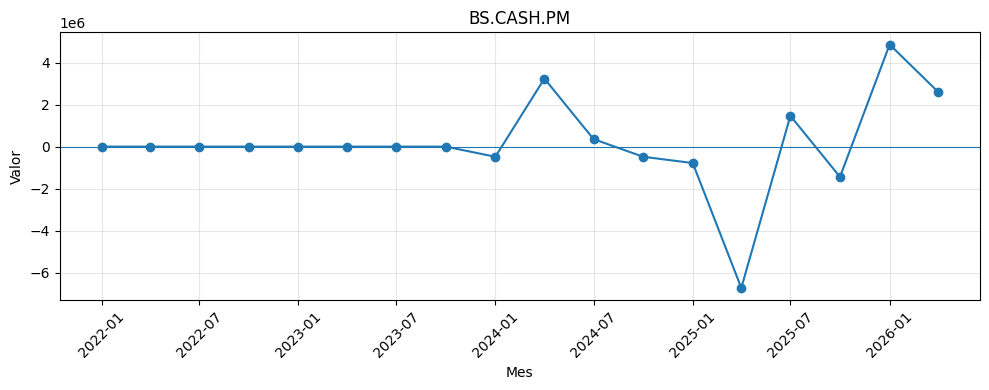

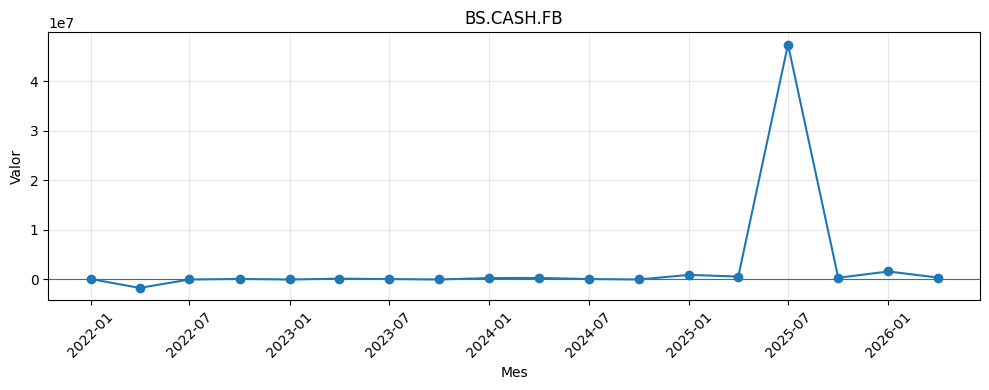

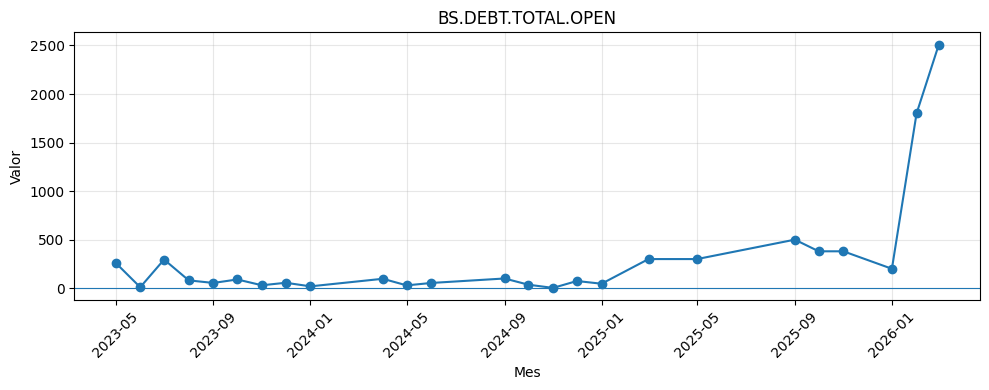

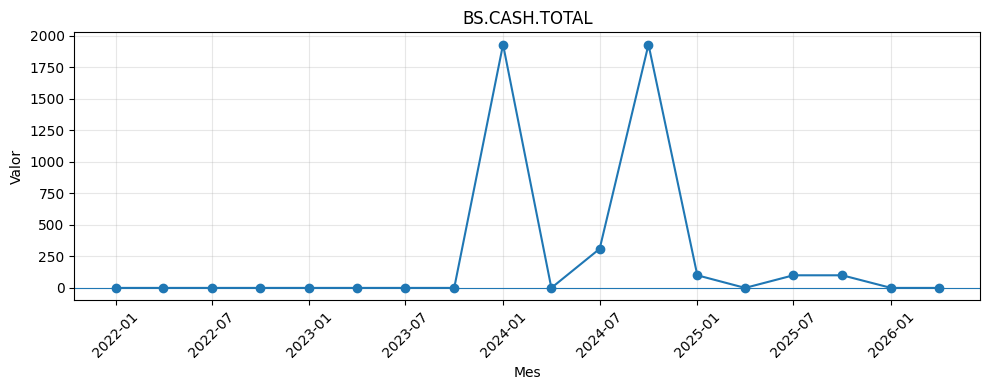

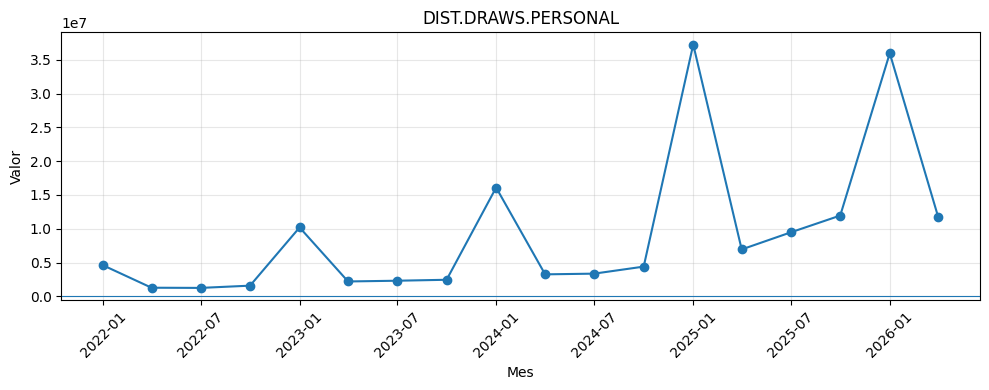

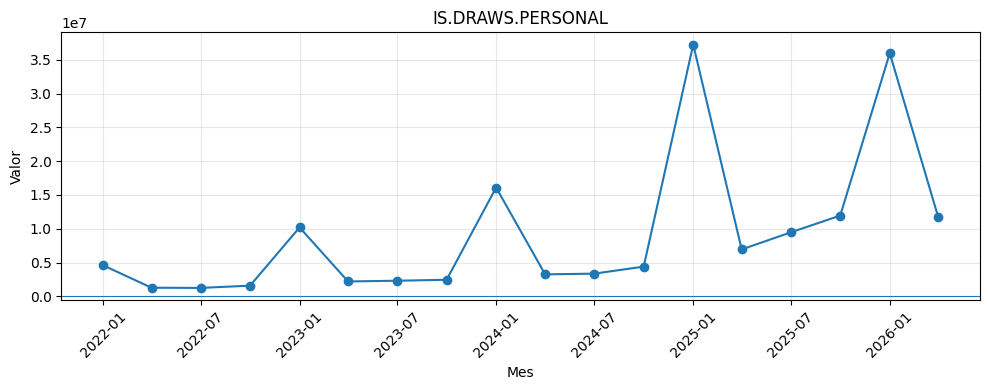

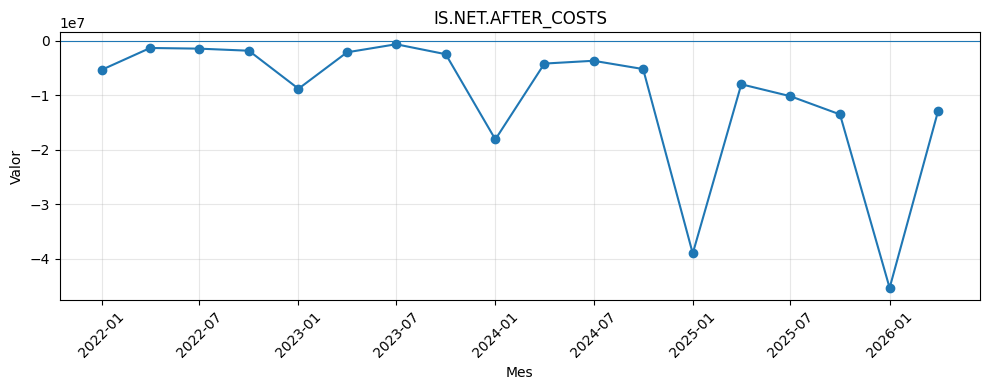

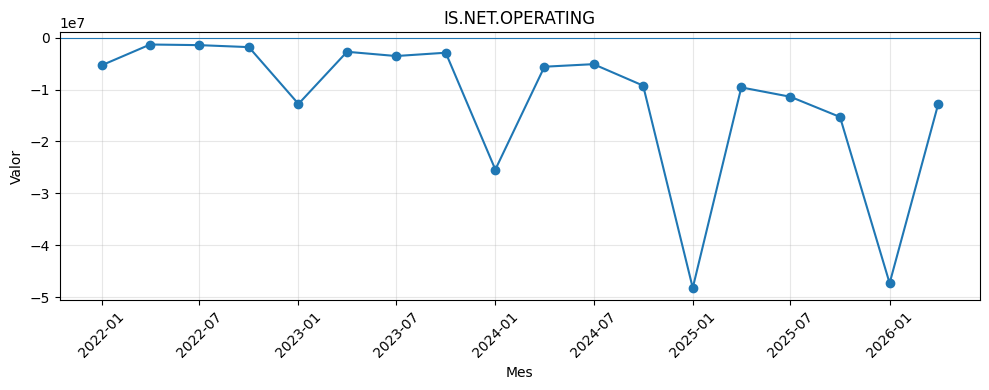

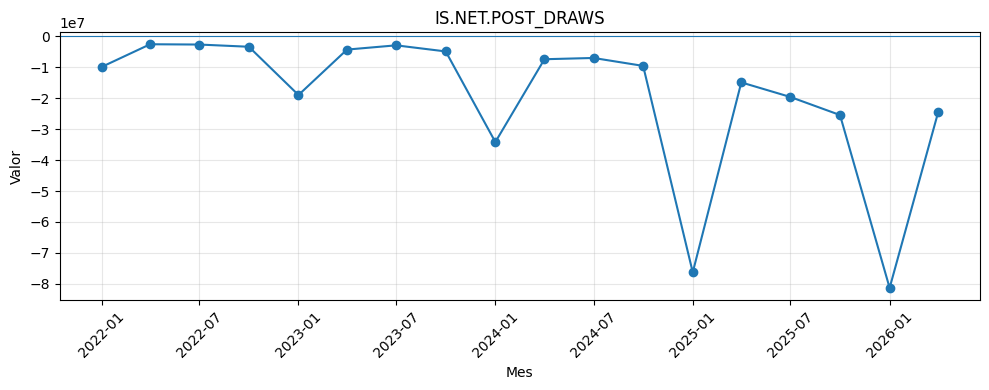

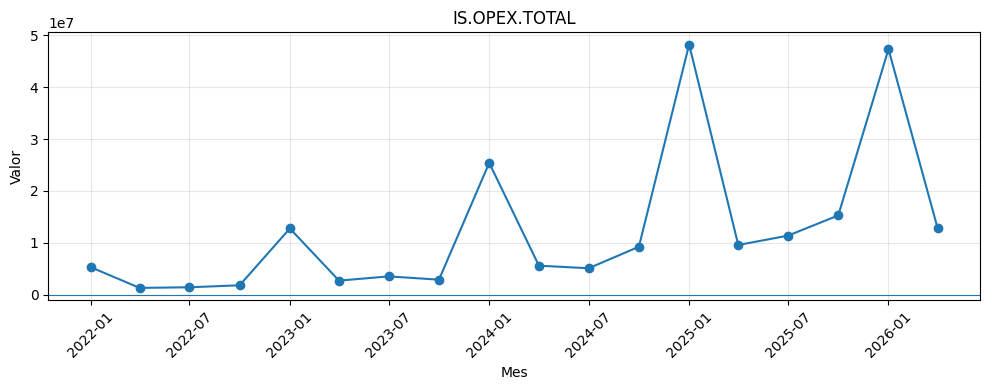

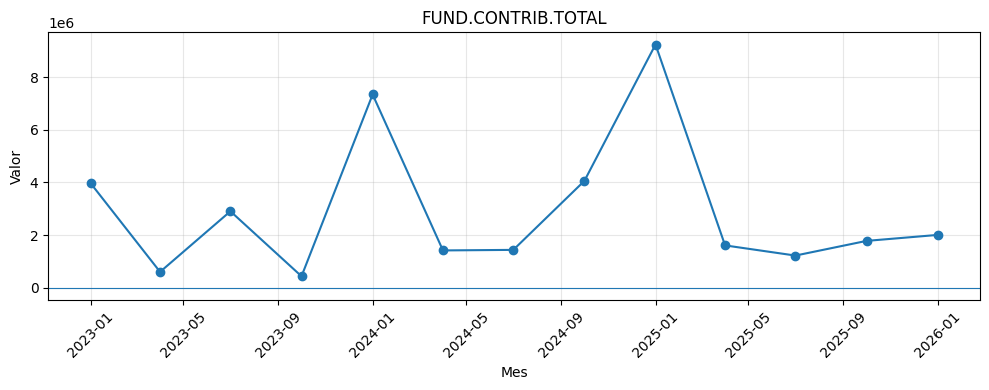

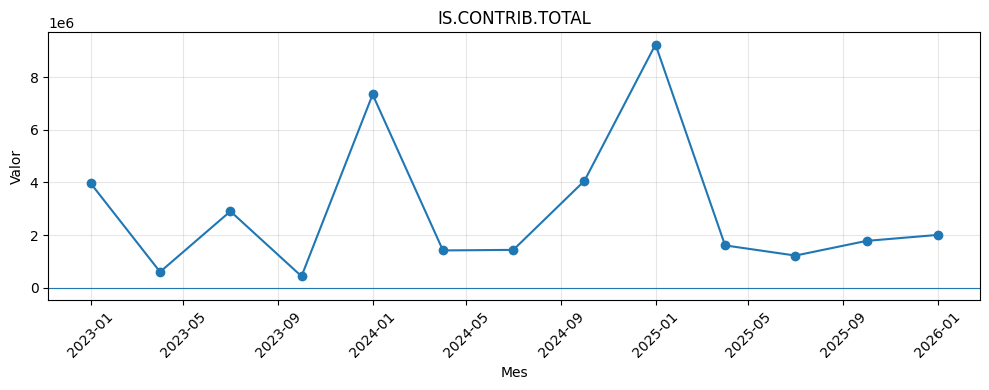

Generated individual plots: 25


In [9]:
def complete_monthly_frame(g):
    g=g.copy(); g["_dt"]=g["month"].map(parse_month_value); g=g.sort_values("_dt")
    idx=pd.date_range(pd.Timestamp(REPORTING_START), pd.Timestamp(REPORTING_END), freq="MS")
    return g.set_index("_dt").reindex(idx)

def plot_single_metric(metric_id, df, output_dir=FIG_INDIV, show=False):
    g=df[df["metric_id"] == metric_id].copy()
    if g.empty: return None
    frame=complete_monthly_frame(g)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(frame.index, frame["value"], width=22, align="center")
    missing=frame["value"].isna()
    if missing.any(): ax.scatter(frame.index[missing], [0]*missing.sum(), marker="x", color="crimson", s=18, label="missing")
    ax.axhline(0, linewidth=0.8)
    ax.set_title(f"{metric_id} — monthly bars")
    ax.set_xlabel("Mes"); ax.set_ylabel("Valor"); ax.tick_params(axis="x", rotation=45); ax.grid(True, axis="y", alpha=0.3)
    if missing.any(): ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    out=output_dir / f"{safe_metric_filename(metric_id)}.png"; fig.savefig(out, dpi=140, bbox_inches="tight")
    plt.show() if show else plt.close(fig)
    return out

individual_plot_rows=[]
metrics_order=review_queue["metric_id"].tolist() if not review_queue.empty else sorted(monthly_selected["metric_id"].unique())
for i, metric_id in enumerate(metrics_order):
    path=plot_single_metric(metric_id, monthly_selected, show=(i < INLINE_REVIEW_LIMIT))
    if path: individual_plot_rows.append({"plot_type":"individual","metric_id":metric_id,"figure_path":str(path),"shown_inline":i < INLINE_REVIEW_LIMIT,"chart_type":"bar"})
individual_plot_index=pd.DataFrame(individual_plot_rows)
individual_plot_index.to_csv(AUDIT / "individual_plot_index.csv", index=False)
print(f"Generated individual plots: {len(individual_plot_index)}")


## 9. Plots grupales con sentido contable

Regla: no más de 2–3 métricas por plot.  
Estos plots no sustituyen la revisión una por una; ayudan a ver coherencia entre métricas relacionadas.

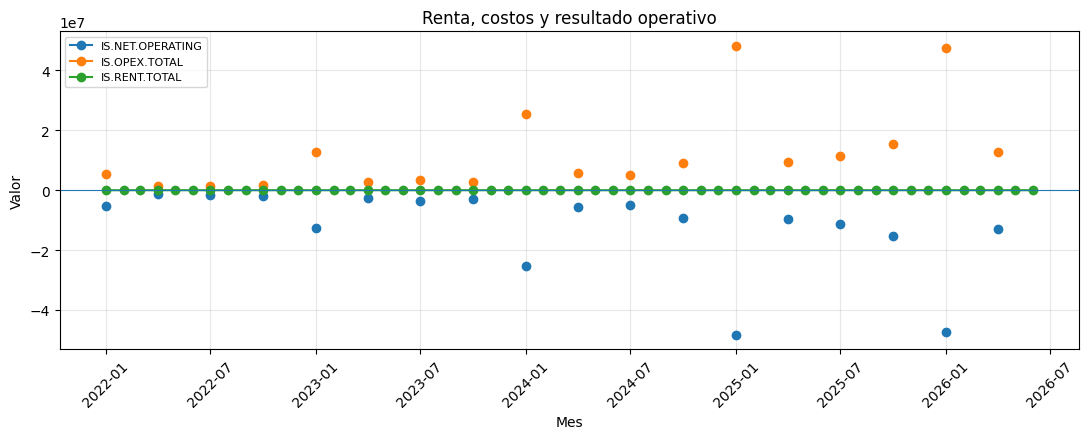

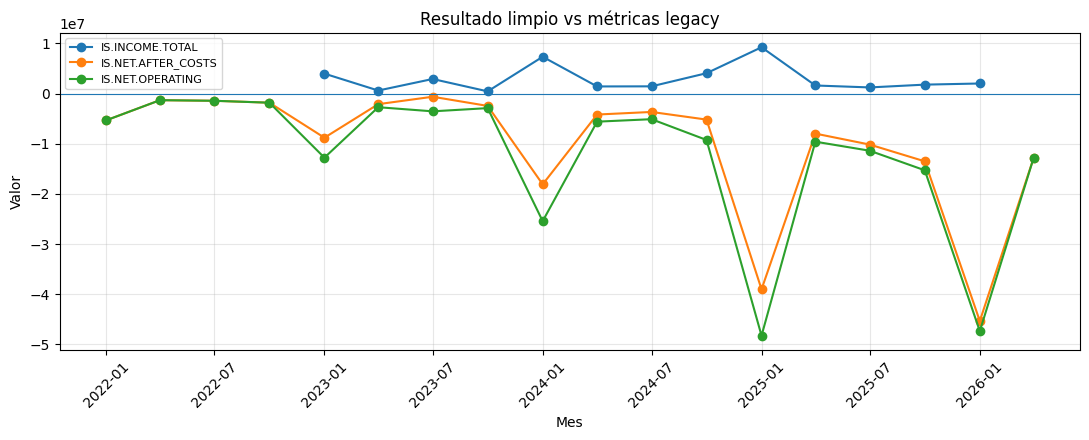

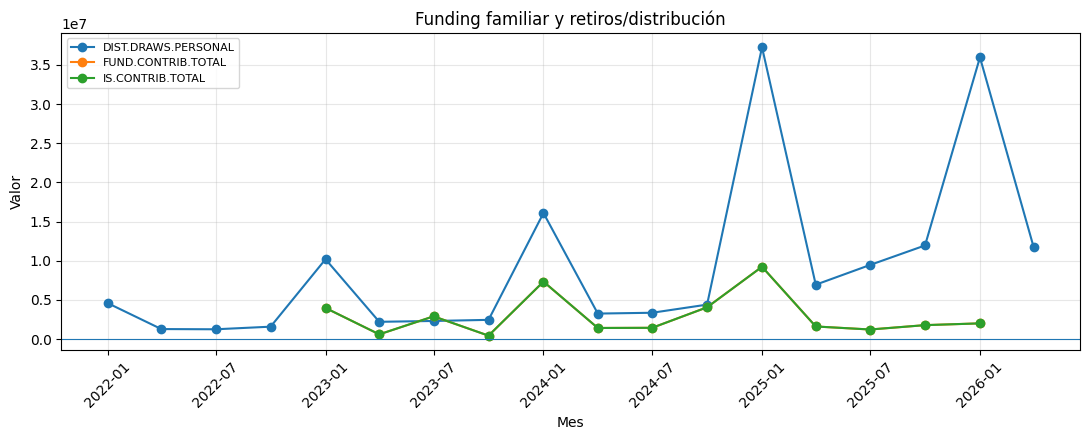

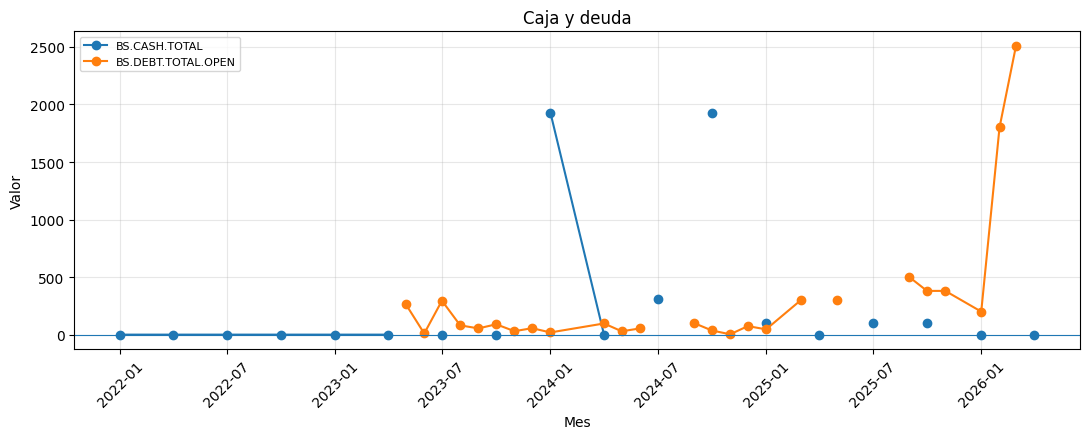

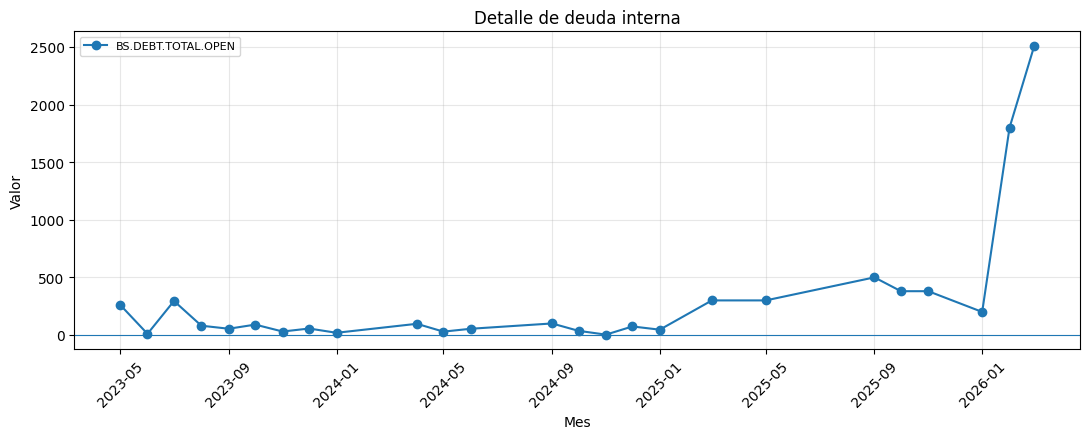

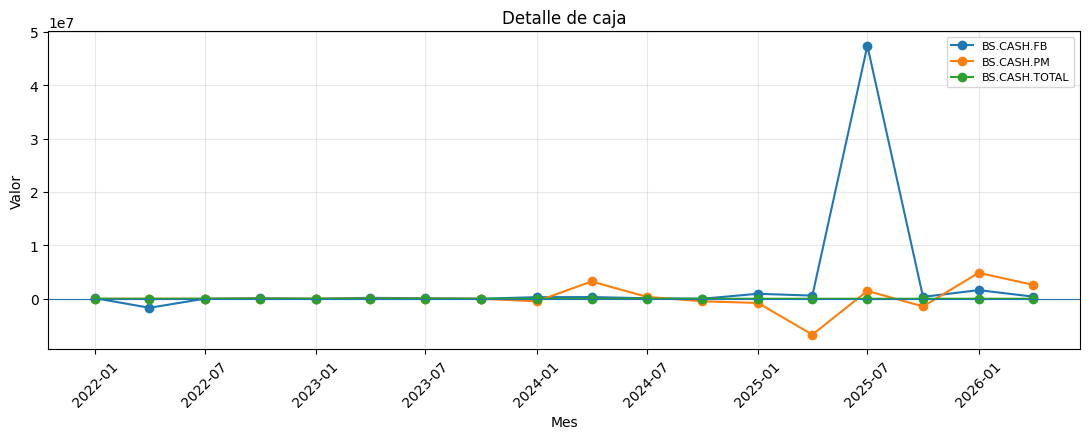

,plot_type,group_id,title,purpose,metrics,n_metrics,status,figure_path
0,group,operating_revenue_costs_result,"Renta, costos y resultado operativo","Ver si el resultado cambia por ingresos, costo...","IS.RENT.TOTAL, IS.OPEX.TOTAL, IS.NET.OPERATING",3,generated,/home/matias/repos/accounting-backend/out/prof...
1,group,legacy_vs_clean_result,Resultado limpio vs métricas legacy,Detectar diferencias entre lectura operativa l...,"IS.NET.OPERATING, IS.NET.AFTER_COSTS, IS.INCOM...",3,generated,/home/matias/repos/accounting-backend/out/prof...
2,group,funding_and_distribution,Funding familiar y retiros/distribución,Ver cuándo la caja se sostuvo por aportes y cu...,"FUND.CONTRIB.TOTAL, DIST.DRAWS.PERSONAL, IS.CO...",3,generated,/home/matias/repos/accounting-backend/out/prof...
3,group,cash_and_debt,Caja y deuda,Contrastar caja visible con exposición de deuda.,"BS.CASH.TOTAL, BS.DEBT.TOTAL.OPEN",2,generated,/home/matias/repos/accounting-backend/out/prof...
4,group,debt_detail,Detalle de deuda interna,Ver movimientos de las principales métricas de...,BS.DEBT.TOTAL.OPEN,1,generated,/home/matias/repos/accounting-backend/out/prof...
5,group,cash_detail,Detalle de caja,Ver movimientos de caja por métrica disponible.,"BS.CASH.FB, BS.CASH.PM, BS.CASH.TOTAL",3,generated,/home/matias/repos/accounting-backend/out/prof...


In [10]:
def metrics_present(candidates):
    present=set(monthly_selected["metric_id"].unique()) if not monthly_selected.empty else set()
    return [m for m in candidates if m in present][:MAX_GROUP_SERIES]

group_specs=[
    {"group_id":"rent_opex_net_operating","title":"Renta, OPEX y resultado operativo","metrics":["IS.RENT.TOTAL","IS.OPEX.TOTAL","IS.NET.OPERATING"],"purpose":"Comparar flows operativos mensuales."},
    {"group_id":"funding_draws","title":"Funding y retiros/distribución","metrics":["FUND.CONTRIB.TOTAL","DIST.DRAWS.PERSONAL"],"purpose":"Comparar flows de aportes y salidas personales."},
    {"group_id":"cash_close_by_box","title":"Caja de cierre por caja y total","metrics":["BS.CASH.FB","BS.CASH.PM","BS.CASH.TOTAL"],"purpose":"Comparar stocks mensuales de cierre de caja."},
    {"group_id":"debt_principal_interest_total","title":"Deuda: principal, interés y total","metrics":["BS.DEBT.PRINCIPAL","BS.DEBT.INTEREST","BS.DEBT.TOTAL.OPEN"],"purpose":"Comparar stocks mensuales de deuda."},
]

def plot_group(group_id,title,metrics,df,show=True):
    metrics=metrics[:MAX_GROUP_SERIES]
    if not metrics: return None
    g=df[df["metric_id"].isin(metrics)].copy()
    if g.empty: return None
    g["_dt"]=g["month"].map(parse_month_value)
    pivot=g.pivot_table(index="_dt", columns="metric_id", values="value", aggfunc="sum").sort_index()
    idx=pd.date_range(pd.Timestamp(REPORTING_START), pd.Timestamp(REPORTING_END), freq="MS"); pivot=pivot.reindex(idx)
    if pivot.empty: return None
    fig, ax=plt.subplots(figsize=(11,4.5))
    x=np.arange(len(pivot.index)); width=0.8/max(1,len(pivot.columns))
    for j,col in enumerate(pivot.columns): ax.bar(x + (j-(len(pivot.columns)-1)/2)*width, pivot[col], width=width, label=col)
    ax.axhline(0, linewidth=0.8); ax.set_title(f"{title} — monthly bars"); ax.set_xlabel("Mes"); ax.set_ylabel("Valor")
    ax.set_xticks(x[::max(1, len(x)//12)]); ax.set_xticklabels([d.strftime("%Y-%m") for d in pivot.index[::max(1, len(x)//12)]], rotation=45, ha="right")
    ax.grid(True, axis="y", alpha=0.3); ax.legend(loc="best", fontsize=8); fig.tight_layout()
    out=FIG_GROUPS / f"{safe_metric_filename(group_id)}.png"; fig.savefig(out, dpi=140, bbox_inches="tight")
    plt.show() if show else plt.close(fig)
    return out

group_plot_rows=[]
for spec in group_specs:
    present=metrics_present(spec["metrics"])
    path=plot_group(spec["group_id"], spec["title"], present, monthly_selected, show=True) if present else None
    group_plot_rows.append({"plot_type":"group","group_id":spec["group_id"],"title":spec["title"],"purpose":spec["purpose"],"metrics":", ".join(present),"n_metrics":len(present),"status":"generated" if path else ("skipped_no_metrics" if not present else "skipped_no_data"),"figure_path":str(path) if path else "","chart_type":"bar"})
group_plot_index=pd.DataFrame(group_plot_rows)
plot_plan=pd.concat([individual_plot_index, group_plot_index], ignore_index=True, sort=False)
plot_plan.to_csv(AUDIT / "plot_plan.csv", index=False)
group_plot_index


## 10. Eventos anómalos destacados

Esta tabla es para revisión práctica: no muestra todas las observaciones, solo eventos que pueden explicar errores o episodios relevantes.

In [11]:
if metric_anomaly_events.empty:
    metric_anomaly_events_display = metric_anomaly_events
else:
    metric_anomaly_events_display = (
        metric_anomaly_events
        .sort_values(["event_type", "metric_id", "month"])
        .head(50)
    )

metric_anomaly_events_display

,metric_id,month,event_type,value,robust_z,note
3,BS.CASH.FB,2022-02,missing_month,NaN,NaN,Mes faltante dentro del rango observado de la ...
4,BS.CASH.FB,2022-03,missing_month,NaN,NaN,Mes faltante dentro del rango observado de la ...
5,BS.CASH.FB,2022-05,missing_month,NaN,NaN,Mes faltante dentro del rango observado de la ...
6,BS.CASH.FB,2022-06,missing_month,NaN,NaN,Mes faltante dentro del rango observado de la ...
7,BS.CASH.FB,2022-08,missing_month,NaN,NaN,Mes faltante dentro del rango observado de la ...
8,BS.CASH.FB,2022-09,missing_month,NaN,NaN,Mes faltante dentro del rango observado de la ...
9,BS.CASH.FB,2022-11,missing_month,NaN,NaN,Mes faltante dentro del rango observado de la ...
10,BS.CASH.FB,2022-12,missing_month,NaN,NaN,Mes faltante dentro del rango observado de la ...
11,BS.CASH.FB,2023-02,missing_month,NaN,NaN,Mes faltante dentro del rango observado de la ...
12,BS.CASH.FB,2023-03,missing_month,NaN,NaN,Mes faltante dentro del rango observado de la ...


## 11. Reporte exportable

El reporte exportado no intenta reemplazar la notebook. Sirve como índice de QA para volver a los plots y tablas.

In [12]:
def df_to_md_table(df, max_rows=12, max_cols=8):
    if df is None or df.empty:
        return "_Sin datos._"
    temp = df.copy().head(max_rows)
    if len(temp.columns) > max_cols:
        temp = temp.iloc[:, :max_cols]
    return temp.to_markdown(index=False)

def df_to_html_table(df, max_rows=20):
    if df is None or df.empty:
        return "<p><em>Sin datos.</em></p>"
    return df.head(max_rows).to_html(index=False, escape=False)

now = datetime.now().strftime("%Y-%m-%d %H:%M")
n_metrics = int(monthly_selected["metric_id"].nunique()) if not monthly_selected.empty else 0
n_rows = len(monthly_selected)
n_flags = int((metric_anomaly_summary["priority_score"] > 0).sum()) if not metric_anomaly_summary.empty else 0

top_review = review_queue[[c for c in [
    "metric_id", "priority_score", "flags", "observed_months", "latest_value",
    "largest_abs_month", "largest_abs_value"
] if c in review_queue.columns]].head(12)

source_table = source_status[["source", "exists", "rows", "cols"]]

md_report = f'''# Monthly metric series audit

_Generado: {now}_  
_Período analizado: {REPORTING_START} a {REPORTING_END}_

## Lectura rápida

Esta auditoría revisa series mensuales de métricas contables para detectar huecos, picos, cambios de signo, rachas de cero y saltos de nivel. No redefine contabilidad ni reemplaza los reportes profesionales; ayuda a decidir qué series merecen revisión antes de usarlas en narrativa.

## Cobertura

- Métricas mensuales seleccionadas: **{n_metrics}**
- Observaciones mensuales seleccionadas: **{n_rows}**
- Métricas con alguna señal de revisión: **{n_flags}**

## Fuentes

{df_to_md_table(source_table, max_rows=10, max_cols=4)}

## Top métricas para revisar

{df_to_md_table(top_review, max_rows=12, max_cols=7)}

## Cómo leer los resultados

1. Si una métrica tiene `spikes`, abrir su plot individual y revisar el mes marcado.
2. Si una métrica tiene `missing_months`, verificar si el dato realmente falta o si cambió la fuente/clasificación.
3. Si hay `sign_changes`, revisar si la métrica debería permitir signo negativo o si hay inversión de criterio.
4. Si hay `zero_run`, revisar si el cero es real, ausencia de actividad o falta de carga.
5. Si el problema afecta una métrica usada por el brief ejecutivo o el reporte operativo, degradar la afirmación a caveat hasta resolverlo.

## Outputs principales

- `monthly_series_selected.csv`
- `metric_series_catalog.csv`
- `metric_anomaly_summary.csv`
- `metric_anomaly_events.csv`
- `plot_plan.csv`
- `figures/individual/*.png`
- `figures/groups/*.png`
'''

html_report = f'''<!doctype html>
<html lang="es">
<head>
<meta charset="utf-8">
<title>Monthly metric series audit</title>
<style>
body {{ font-family: system-ui, -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif; max-width: 960px; margin: 40px auto; padding: 0 24px 48px; color: #1f2937; line-height: 1.45; }}
h1 {{ font-size: 30px; border-bottom: 2px solid #d1d5db; padding-bottom: 10px; }}
h2 {{ margin-top: 28px; font-size: 21px; color: #111827; }}
table {{ border-collapse: collapse; width: 100%; font-size: 13px; margin: 12px 0; }}
th, td {{ border: 1px solid #e5e7eb; padding: 6px 8px; text-align: left; vertical-align: top; }}
th {{ background: #f9fafb; }}
code {{ background: #f3f4f6; padding: 2px 5px; border-radius: 4px; }}
.footer {{ margin-top: 36px; padding-top: 12px; border-top: 1px solid #e5e7eb; color: #6b7280; font-size: 13px; }}
</style>
</head>
<body>
<h1>Monthly metric series audit</h1>
<p><em>Generado: {html.escape(now)}</em></p>
<p><em>Período analizado: {html.escape(REPORTING_START)} a {html.escape(REPORTING_END)}</em></p>

<h2>Lectura rápida</h2>
<p>Esta auditoría revisa series mensuales de métricas contables para detectar huecos, picos, cambios de signo, rachas de cero y saltos de nivel. No redefine contabilidad ni reemplaza los reportes profesionales; ayuda a decidir qué series merecen revisión antes de usarlas en narrativa.</p>

<h2>Cobertura</h2>
<ul>
<li>Métricas mensuales seleccionadas: <strong>{n_metrics}</strong></li>
<li>Observaciones mensuales seleccionadas: <strong>{n_rows}</strong></li>
<li>Métricas con alguna señal de revisión: <strong>{n_flags}</strong></li>
</ul>

<h2>Fuentes</h2>
{df_to_html_table(source_table, max_rows=10)}

<h2>Top métricas para revisar</h2>
{df_to_html_table(top_review, max_rows=12)}

<h2>Cómo leer los resultados</h2>
<ol>
<li>Si una métrica tiene <code>spikes</code>, abrir su plot individual y revisar el mes marcado.</li>
<li>Si una métrica tiene <code>missing_months</code>, verificar si el dato realmente falta o si cambió la fuente/clasificación.</li>
<li>Si hay <code>sign_changes</code>, revisar si la métrica debería permitir signo negativo o si hay inversión de criterio.</li>
<li>Si hay <code>zero_run</code>, revisar si el cero es real, ausencia de actividad o falta de carga.</li>
<li>Si el problema afecta una métrica usada por el brief ejecutivo o el reporte operativo, degradar la afirmación a caveat hasta resolverlo.</li>
</ol>

<h2>Outputs principales</h2>
<ul>
<li><code>monthly_series_selected.csv</code></li>
<li><code>metric_series_catalog.csv</code></li>
<li><code>metric_anomaly_summary.csv</code></li>
<li><code>metric_anomaly_events.csv</code></li>
<li><code>plot_plan.csv</code></li>
<li><code>figures/individual/*.png</code></li>
<li><code>figures/groups/*.png</code></li>
</ul>

<div class="footer">Generated by notebooks/accounting/04_monthly_metric_series_audit.ipynb</div>
</body>
</html>
'''

(AUDIT / "monthly_series_audit_report.md").write_text(md_report, encoding="utf-8")
(AUDIT / "monthly_series_audit_report.html").write_text(html_report, encoding="utf-8")

print(AUDIT / "monthly_series_audit_report.md")
print(AUDIT / "monthly_series_audit_report.html")

/home/matias/repos/accounting-backend/out/professional_pack/latest/monthly_series_audit/monthly_series_audit_report.md
/home/matias/repos/accounting-backend/out/professional_pack/latest/monthly_series_audit/monthly_series_audit_report.html


## 12. QA final

El criterio mínimo de cierre no es “no hay anomalías”; es que la notebook haya encontrado fuentes, producido catálogo, plots y una cola de revisión.

In [13]:
monthly_actual_count = int((source_granularity_audit["detected_granularity"] == "monthly_actual").sum()) if not source_granularity_audit.empty else 0
non_monthly_count = int((~source_granularity_audit["is_monthly_usable"].fillna(False)).sum()) if not source_granularity_audit.empty else 0
mislabeled = source_granularity_audit[(source_granularity_audit["detected_granularity"].eq("quarterly_or_periodic")) & (source_granularity_audit["is_monthly_usable"].fillna(False))] if not source_granularity_audit.empty else pd.DataFrame()
qa_rows = [
    {"check":"monthly_series_available","status":"PASS" if not monthly_selected.empty else "FAIL","detail":f"{len(monthly_selected)} selected rows"},
    {"check":"metric_catalog_available","status":"PASS" if not metric_catalog.empty else "FAIL","detail":f"{len(metric_catalog)} metrics in catalog"},
    {"check":"anomaly_summary_available","status":"PASS" if not metric_anomaly_summary.empty else "FAIL","detail":f"{len(metric_anomaly_summary)} rows"},
    {"check":"no_quarterly_source_mislabeled_as_monthly","status":"PASS" if mislabeled.empty else "FAIL","detail":f"{len(mislabeled)} mislabeled quarterly sources"},
    {"check":"source_granularity_audit_exists","status":"PASS" if (AUDIT / "source_granularity_audit.csv").exists() else "FAIL","detail":str(AUDIT / "source_granularity_audit.csv")},
    {"check":"bar_plots_generated","status":"PASS" if len(individual_plot_index) > 0 and individual_plot_index.get("chart_type", pd.Series()).eq("bar").all() else "WARN","detail":f"{len(individual_plot_index)} individual bar plots"},
    {"check":"monthly_actual_metrics_count","status":"PASS" if monthly_actual_count > 0 else "WARN","detail":str(monthly_actual_count)},
    {"check":"non_monthly_metrics_count","status":"PASS","detail":str(non_monthly_count)},
    {"check":"operating_result_monthly_preferred_when_available","status":"PASS" if operating_monthly.empty or "operating_result_monthly" in set(source_choice.get("source", [])) else "WARN","detail":"operating_result_monthly participates in source priority"},
    {"check":"debt_balance_monthly_preferred_when_available","status":"PASS" if stage_d_frames["debt_balance_monthly"].empty or "debt_balance_monthly" in set(source_choice.get("source", [])) else "WARN","detail":"debt_balance_monthly participates in source priority"},
    {"check":"report_exported","status":"PASS" if (AUDIT / "monthly_series_audit_report.md").exists() else "FAIL","detail":str(AUDIT / "monthly_series_audit_report.md")},
]
qa = pd.DataFrame(qa_rows)
qa.to_csv(AUDIT / "monthly_series_audit_qa.csv", index=False)
print("MONTHLY SERIES AUDIT V0.2 SUMMARY")
print(f"- Metrics audited: {monthly_selected['metric_id'].nunique() if not monthly_selected.empty else 0}")
print(f"- Monthly actual metrics: {monthly_actual_count}")
print(f"- Monthly partial metrics: {int((source_granularity_audit['detected_granularity'] == 'monthly_partial').sum()) if not source_granularity_audit.empty else 0}")
print(f"- Non-monthly/quarterly metrics: {non_monthly_count}")
print(f"- Metrics whose source changed: see monthly_series_source_choice.csv")
print(f"- Metrics still needing monthly source clarification: {int(source_granularity_audit['codex_question'].astype(str).str.contains('true monthly source', na=False).sum()) if not source_granularity_audit.empty else 0}")
print(f"- Individual bar plots generated: {len(individual_plot_index)}")
print(f"- Group bar plots generated: {int(group_plot_index['status'].eq('generated').sum()) if not group_plot_index.empty else 0}")
qa


,check,status,detail
0,monthly_series_available,PASS,412 selected rows
1,metric_catalog_available,PASS,25 metrics in catalog
2,anomaly_summary_available,PASS,25 rows
3,individual_plots_generated,PASS,25 individual plots
4,group_plots_attempted,PASS,6 group specs
5,report_exported,PASS,/home/matias/repos/accounting-backend/out/prof...


## 13. Próximo paso

Después de correr esta notebook:

1. Revisar `metric_review_queue.csv`.
2. Abrir los plots individuales de las métricas con `priority_score` alto.
3. Si una anomalía afecta `01` o `02`, degradar el claim o corregir la fuente.
4. Si una métrica falta como mensual, decidir si corresponde elevarla al registry mensual o dejarla como quarterly/yearly.
5. Usar `plot_plan.csv` como índice para navegar la carpeta de figuras.

La salida útil no es solo un gráfico: es una lista priorizada de sospechas.